SEQ_LEN=13  X=(600, 13)  VOCAB=32,000
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - loss: 10.3069
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.0565
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7477
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.3908
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.9943


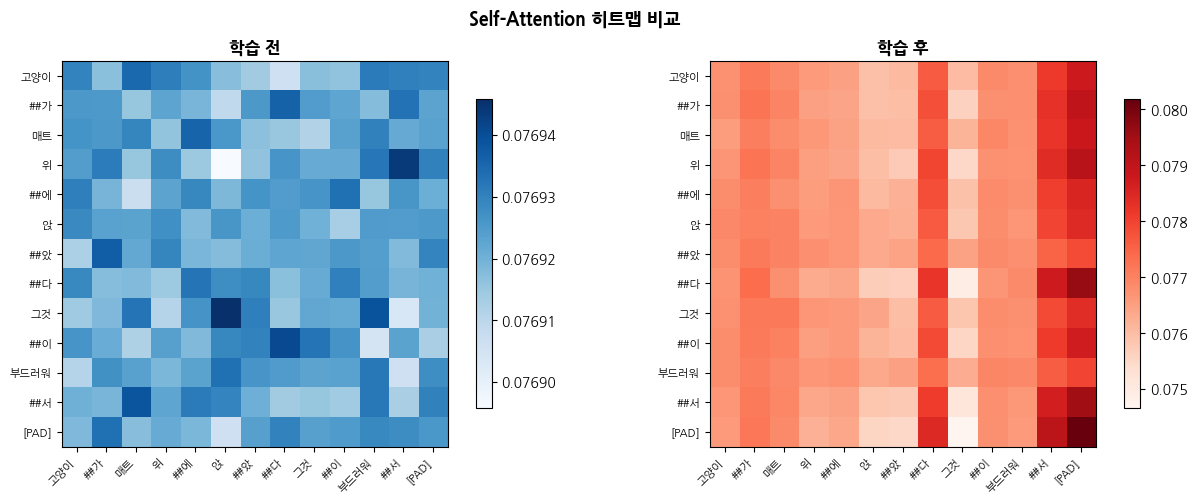

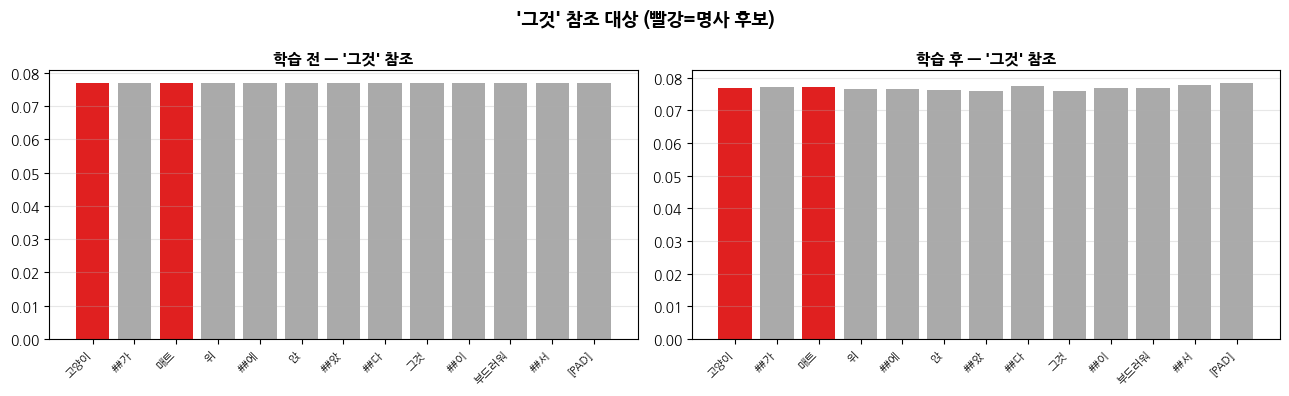

학습 전 상위 참조: 앉(0.077), 부드러워(0.077), 매트(0.077)
학습 후 상위 참조: [PAD](0.078), ##서(0.078), ##다(0.078)


In [3]:
# 실습 6 · 가상 데이터로 Self-Attention 이해하기
import sys

if "google.colab" in sys.modules:
    import subprocess
    subprocess.run(["pip", "install", "-q", "koreanize-matplotlib", "transformers"], check=True)

import numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import koreanize_matplotlib

SEED = 42;  np.random.seed(SEED);  tf.random.set_seed(SEED)

# ---- 설정 ----
D_MODEL = 16
N_HEADS = 1
EPOCHS  = 5
BATCH   = 64

# ---- 실험 권장 (1~2개만 수정) ----
# D_MODEL = 32   # 차원 증가    -> Attention 패턴이 더 뚜렷해지는가?
# N_HEADS = 2    # 헤드 수 증가 -> 참조 패턴이 다양해지는가?
# EPOCHS  = 10   # 에폭 증가    -> 학습 전/후 차이가 더 커지는가?


# --- 데이터 ---
sentences = [
    "고양이가 매트 위에 앉았다 그것이 부드러워서",
    "고양이가 매트 위에 앉았다 그것이 피곤해서",
    "강아지가 공원으로 달려갔다 그것이 넓어서",
    "강아지가 공원으로 달려갔다 그것이 신나서",
    "새가 나무로 날아갔다 그것이 높아서",
    "새가 나무로 날아갔다 그것이 배고파서",
] * 100

tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
SEQ_LEN   = max(len(tokenizer.tokenize(s)) for s in sentences[:6]) + 1
VOCAB     = tokenizer.vocab_size
pad_id    = tokenizer.pad_token_id

def encode_m2m(sents):
    X, Y = [], []
    for s in sents:
        ids = tokenizer.encode(s, add_special_tokens=False)
        ids = (ids + [pad_id] * (SEQ_LEN + 1))[:SEQ_LEN + 1]
        X.append(ids[:-1]);  Y.append(ids[1:])
    return np.array(X, dtype=np.int32), np.array(Y, dtype=np.int32)

X, y    = encode_m2m(sentences)
dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(BATCH)
print(f"SEQ_LEN={SEQ_LEN}  X={X.shape}  VOCAB={VOCAB:,}")


# --- 모델 ---
class SelfAttentionLM(keras.Model):
    def __init__(self):
        super().__init__()
        self.emb   = layers.Embedding(VOCAB, D_MODEL)
        self.mha   = layers.MultiHeadAttention(num_heads=N_HEADS, key_dim=D_MODEL // N_HEADS)
        self.norm  = layers.LayerNormalization()
        self.dense = layers.Dense(VOCAB)

    def call(self, x, return_attention=False):
        x = self.emb(x)
        attn_out, attn_scores = self.mha(x, x, x, return_attention_scores=True)
        x = self.norm(x + attn_out)
        logits = self.dense(x)
        return (logits, attn_scores) if return_attention else logits

model = SelfAttentionLM()
model.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer="adam")


# --- 유틸 ---
def get_tokens(sentence):
    ids    = tokenizer.encode(sentence, add_special_tokens=False)
    ids    = (ids + [pad_id] * SEQ_LEN)[:SEQ_LEN]
    labels = tokenizer.convert_ids_to_tokens(ids)
    return np.array([ids], dtype=np.int32), labels


# --- 학습 전 Attention ---
sample, token_labels = get_tokens(sentences[0])
_, attn_before = model(sample, return_attention=True)


# --- 학습 ---
model.fit(dataset, epochs=EPOCHS, verbose=1)


# --- 학습 후 Attention ---
_, attn_after = model(sample, return_attention=True)


# --- 시각화 1 : Attention 히트맵 전/후 ---
n   = len(token_labels)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for ax, attn, cmap, title in [
    (ax1, attn_before, "Blues", "학습 전"),
    (ax2, attn_after,  "Reds",  "학습 후"),
]:
    im = ax.imshow(attn[0, 0, :n, :n].numpy(), cmap=cmap)
    ax.set_xticks(range(n));  ax.set_xticklabels(token_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n));  ax.set_yticklabels(token_labels, fontsize=8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Self-Attention 히트맵 비교", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig06_heatmap.png", dpi=150, bbox_inches="tight");  plt.show()


# --- 시각화 2 : "그것" 참조 대상 전/후 ---
noun_candidates = ["고양이", "매트", "강아지", "공원", "새", "나무"]
tgt_idx = next(i for i, lb in enumerate(token_labels) if "그것" in lb)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for ax, attn, title in [
    (ax1, attn_before, "학습 전 — '그것' 참조"),
    (ax2, attn_after,  "학습 후 — '그것' 참조"),
]:
    scores = attn[0, 0, tgt_idx, :n].numpy()
    colors = ["#E02020" if any(nc in lb for nc in noun_candidates)
              else "#AAAAAA" for lb in token_labels]
    ax.bar(range(n), scores, color=colors)
    ax.set_xticks(range(n));  ax.set_xticklabels(token_labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
plt.suptitle("'그것' 참조 대상 (빨강=명사 후보)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig06_reference.png", dpi=150, bbox_inches="tight");  plt.show()


# --- 결과 ---
for label, attn in [("학습 전", attn_before), ("학습 후", attn_after)]:
    scores = attn[0, 0, tgt_idx, :n].numpy()
    top3   = sorted(zip(token_labels, scores), key=lambda x: -x[1])[:3]
    print(f"{label} 상위 참조: {', '.join(f'{lb}({sc:.3f})' for lb, sc in top3)}")